# Coffee Shop Chain Sales Performance Analysis
## Phase 2: Data Profiling & Exploratory Data Analysis (EDA)
**Dataset:** Coffee Shop Sales (Jan–Jun 2023) | 149,116 transactions | 3 NYC locations

### 2.1 Setup & Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Load dataset
df = pd.read_csv(r'C:\project\eda\myenv\data\Project.csv')
print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (149116, 18)


### 2.2 Initial Inspection
We examine the structure, data types, and a statistical summary of the dataset.

In [4]:
# Basic structure
print("=== DATA TYPES ===")
print(df.dtypes)
print("\n=== FIRST 5 ROWS ===")
df.head()

=== DATA TYPES ===
transaction_id        int64
transaction_date        str
transaction_time        str
store_id              int64
store_location          str
product_id            int64
transaction_qty       int64
unit_price          float64
Total_Bill          float64
product_category        str
product_type            str
product_detail          str
Size                    str
Month Name              str
Day Name                str
Hour                  int64
Month                 int64
Day of Week           int64
dtype: object

=== FIRST 5 ROWS ===


,transaction_id,transaction_date,transaction_time,store_id,store_location,product_id,transaction_qty,unit_price,Total_Bill,product_category,product_type,product_detail,Size,Month Name,Day Name,Hour,Month,Day of Week
0,114301,01-06-2023,11:33:29,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Thursday,11,6,3
1,115405,02-06-2023,11:18:24,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Friday,11,6,4
2,115478,02-06-2023,12:02:45,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Friday,12,6,4
3,116288,02-06-2023,19:39:47,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Friday,19,6,4
4,116714,03-06-2023,12:24:57,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Saturday,12,6,5


In [5]:
# Statistical summary of numeric columns
print("=== DESCRIPTIVE SUMMARY ===")
df.describe().round(2)

=== DESCRIPTIVE SUMMARY ===


,transaction_id,store_id,product_id,transaction_qty,unit_price,Total_Bill,Hour,Month,Day of Week
count,149116.00,149116.00,149116.00,149116.00,149116.00,149116.00,149116.00,149116.00,149116.00
mean,74737.37,5.34,47.92,1.44,3.38,4.69,11.74,3.99,2.98
std,43153.60,2.07,17.93,0.54,2.66,4.23,3.76,1.67,2.00
min,1.00,3.00,1.00,1.00,0.80,0.80,6.00,1.00,0.00
25%,37335.75,3.00,33.00,1.00,2.50,3.00,9.00,3.00,1.00
50%,74727.50,5.00,47.00,1.00,3.00,3.75,11.00,4.00,3.00
75%,112094.25,8.00,60.00,2.00,3.75,6.00,15.00,5.00,5.00
max,149456.00,8.00,87.00,8.00,45.00,360.00,20.00,6.00,6.00


In [6]:
# Full info overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   transaction_date  149116 non-null  str    
 2   transaction_time  149116 non-null  str    
 3   store_id          149116 non-null  int64  
 4   store_location    149116 non-null  str    
 5   product_id        149116 non-null  int64  
 6   transaction_qty   149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   Total_Bill        149116 non-null  float64
 9   product_category  149116 non-null  str    
 10  product_type      149116 non-null  str    
 11  product_detail    149116 non-null  str    
 12  Size              149116 non-null  str    
 13  Month Name        149116 non-null  str    
 14  Day Name          149116 non-null  str    
 15  Hour              149116 non-null  int64  
 16  Month             149116 non-nu

### 2.3 Missing Value Analysis
We check for null values across all columns and decide how to handle them.

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("No missing values found. Dataset is complete.")
else:
    print(missing_df)

No missing values found. Dataset is complete.


In [ ]:
# Since there are no missing values, we confirm with a summary table instead
completeness = pd.DataFrame({
    'Column': df.columns,
    'Non-Null Count': df.notnull().sum().values,
    'Missing Count': df.isnull().sum().values,
    'Complete %': (df.notnull().sum().values / len(df) * 100).round(2)
})

print("=== DATASET COMPLETENESS REPORT ===")
print(completeness.to_string(index=False))
print(f"\nAll {len(df.columns)} columns are 100% complete. No treatment required.")

=== DATASET COMPLETENESS REPORT ===
          Column  Non-Null Count  Missing Count  Complete %
  transaction_id          149116              0       100.0
transaction_date          149116              0       100.0
transaction_time          149116              0       100.0
        store_id          149116              0       100.0
  store_location          149116              0       100.0
      product_id          149116              0       100.0
 transaction_qty          149116              0       100.0
      unit_price          149116              0       100.0
      Total_Bill          149116              0       100.0
product_category          149116              0       100.0
    product_type          149116              0       100.0
  product_detail          149116              0       100.0
            Size          149116              0       100.0
      Month Name          149116              0       100.0
        Day Name          149116              0       100.0
    

### 2.4 Data Type Corrections
Convert date and time columns to proper formats for time-series analysis.

In [9]:
# Convert date and time to proper types
df['transaction_date'] = pd.to_datetime(df['transaction_date'], dayfirst=True, format='%d-%m-%Y')
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.time

# Verify
print(df[['transaction_date', 'transaction_time']].dtypes)
print(df[['transaction_date', 'transaction_time']].head())

transaction_date    datetime64[us]
transaction_time            object
dtype: object
  transaction_date transaction_time
0       2023-06-01         11:33:29
1       2023-06-02         11:18:24
2       2023-06-02         12:02:45
3       2023-06-02         19:39:47
4       2023-06-03         12:24:57


### 2.5 Outlier Detection
We use the IQR method to detect outliers in the three key numeric variables:
`transaction_qty`, `unit_price`, and `Total_Bill`.

In [10]:
numeric_cols = ['transaction_qty', 'unit_price', 'Total_Bill']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%) | Lower: {lower:.2f} | Upper: {upper:.2f}")

transaction_qty: 36 outliers (0.02%) | Lower: -0.50 | Upper: 3.50
unit_price: 4212 outliers (2.82%) | Lower: 0.62 | Upper: 5.62
Total_Bill: 3273 outliers (2.19%) | Lower: -1.50 | Upper: 10.50


In [18]:
# Z-score outlier check (supplementary method)
from scipy import stats

print("=== Z-SCORE OUTLIER CHECK (threshold: |z| > 3) ===")
for col in numeric_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    outliers_z = df[z_scores > 3]
    print(f"{col}: {len(outliers_z)} outliers ({len(outliers_z)/len(df)*100:.2f}%)")

=== Z-SCORE OUTLIER CHECK (threshold: |z| > 3) ===
transaction_qty: 36 outliers (0.02%)
unit_price: 2514 outliers (1.69%)
Total_Bill: 1545 outliers (1.04%)


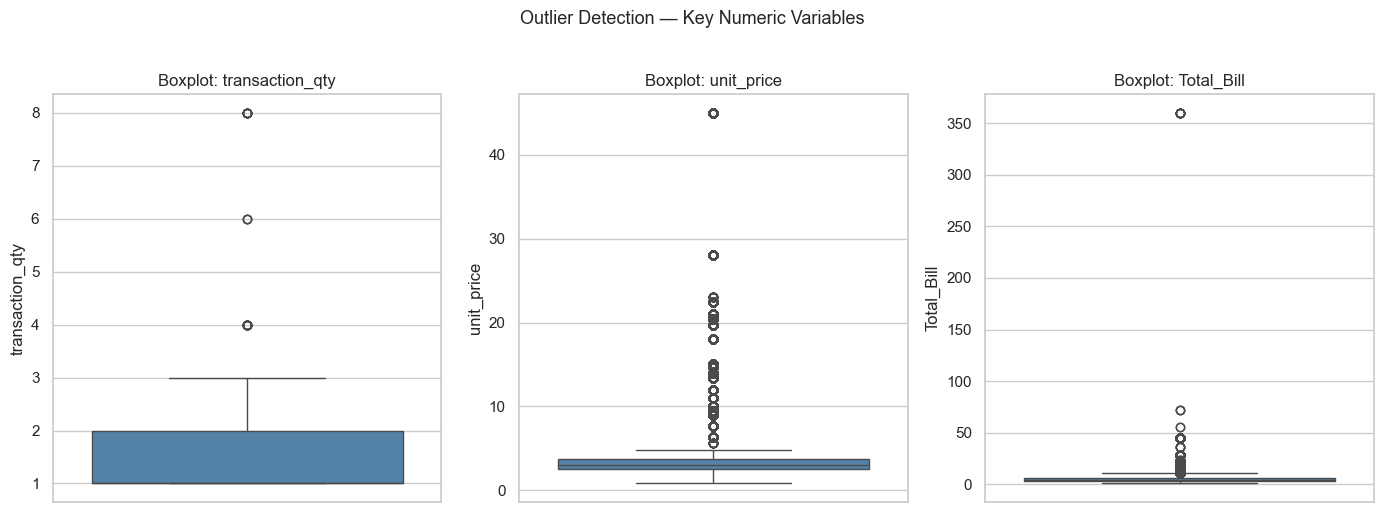

In [11]:
# Boxplots to visualize outliers
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel(col)

plt.suptitle('Outlier Detection — Key Numeric Variables', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** Transaction quantity outliers (only 36, or 0.02%) are negligible and likely represent bulk or catering orders — safe to keep in the dataset. Unit price outliers (2.82%) reflect premium products like specialty beans or merchandise, which are legitimate data points. Total_Bill outliers (2.19%) are driven by high-unit-price items rather than data errors.

### 2.6 Distribution Analysis
We examine the distribution shape of all numeric variables using histograms and KDE plots.

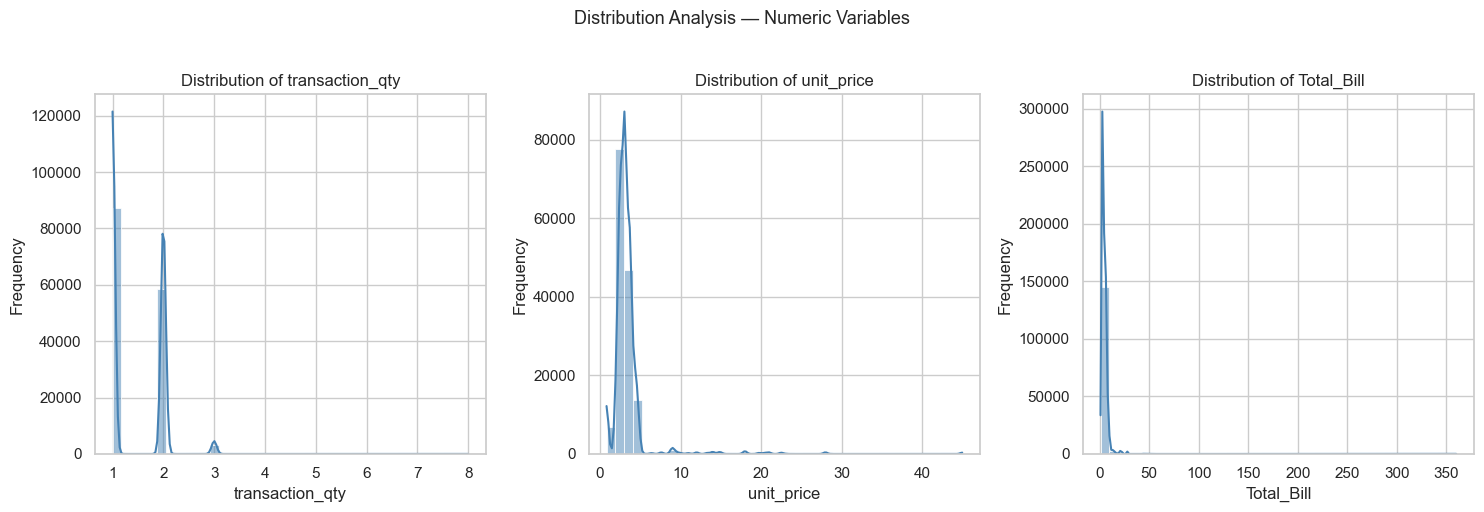

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=40)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution Analysis — Numeric Variables', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** All three numeric variables are right-skewed, with Total_Bill showing an extreme skewness of 41.75 — meaning the overwhelming majority of transactions are small-ticket purchases under $10, with a tiny fraction of high-value orders pulling the mean upward. This is typical of a high-frequency café environment. The median ($3.75) is a more reliable measure of the typical transaction than the mean ($4.69).

In [13]:
# Skewness and kurtosis
print("=== SKEWNESS & KURTOSIS ===")
for col in numeric_cols:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    print(f"{col}: Skewness = {skew:.3f} | Kurtosis = {kurt:.3f}")

=== SKEWNESS & KURTOSIS ===
transaction_qty: Skewness = 0.800 | Kurtosis = 0.824
unit_price: Skewness = 8.455 | Kurtosis = 98.919
Total_Bill: Skewness = 41.746 | Kurtosis = 3359.755


**Note on skewness:** A skewness above 1.0 is considered highly skewed. Total_Bill at 41.75 and unit_price at 8.46 are both extreme — this is explained by a small number of premium products (e.g., coffee beans, merchandise) that are priced far above the typical $2–$5 drink. These are not errors; they represent a genuinely different purchase type.

### 2.7 Correlation Matrix
We examine linear relationships between the numeric variables.

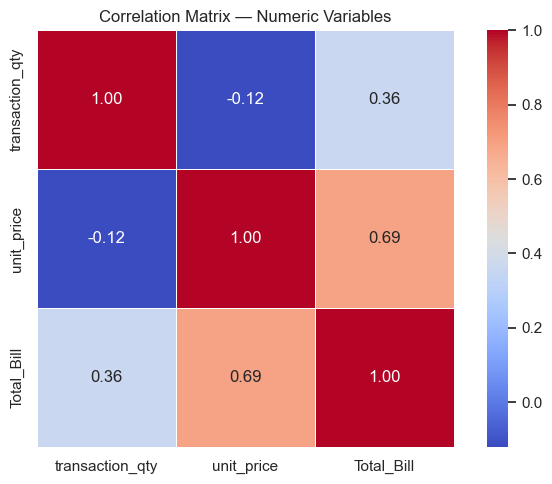

                 transaction_qty  unit_price  Total_Bill
transaction_qty             1.00       -0.12        0.36
unit_price                 -0.12        1.00        0.69
Total_Bill                  0.36        0.69        1.00


In [14]:
corr_matrix = df[numeric_cols].corr().round(2)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — Numeric Variables')
plt.tight_layout()
plt.show()

print(corr_matrix)

**Interpretation:** Unit price has the strongest relationship with Total_Bill (r = 0.69), meaning what drives a higher bill is primarily *what* a customer orders, not *how many* items they buy. Transaction quantity has a weaker positive relationship (r = 0.36), suggesting most customers order 1–2 items regardless of price. The slight negative correlation between unit_price and transaction_qty (r = -0.12) hints that customers ordering premium-priced items tend to buy fewer units.

### 2.8 Categorical Variable Overview
A quick look at the unique values and distribution of key categorical columns.

In [15]:
cat_cols = ['store_location', 'product_category', 'product_type', 'Size']

for col in cat_cols:
    print(f"\n=== {col.upper()} ===")
    print(df[col].value_counts())


=== STORE_LOCATION ===
store_location
Hell's Kitchen     50735
Astoria            50599
Lower Manhattan    47782
Name: count, dtype: int64

=== PRODUCT_CATEGORY ===
product_category
Coffee                58416
Tea                   45449
Bakery                22796
Drinking Chocolate    11468
Flavours               6790
Coffee beans           1753
Loose Tea              1210
Branded                 747
Packaged Chocolate      487
Name: count, dtype: int64

=== PRODUCT_TYPE ===
product_type
Brewed Chai tea          17183
Gourmet brewed coffee    16912
Barista Espresso         16403
Hot chocolate            11468
Brewed Black tea         11350
Brewed herbal tea        11245
Scone                    10173
Organic brewed coffee     8489
Drip coffee               8477
Premium brewed coffee     8135
Pastry                    6912
Biscotti                  5711
Brewed Green tea          5671
Regular syrup             4979
Sugar free syrup          1811
Housewares                 526
Chai tea

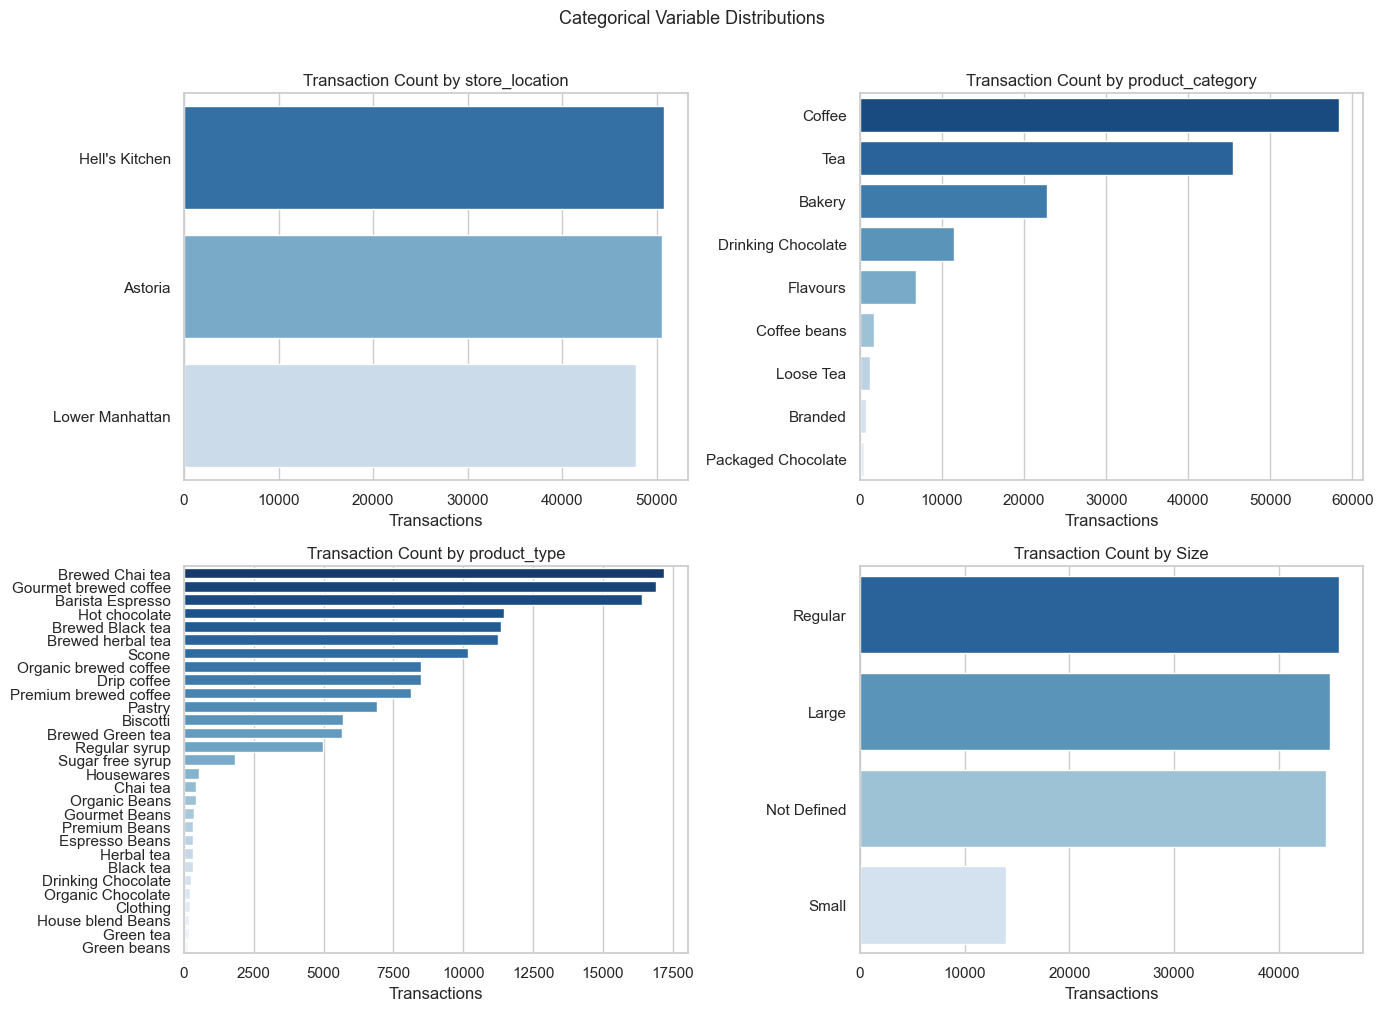

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts().reset_index()
    counts.columns = [col, 'count']
    sns.barplot(data=counts, x='count', y=col, ax=axes[i],
                hue=col, palette='Blues_r', legend=False)
    axes[i].set_title(f'Transaction Count by {col}')
    axes[i].set_xlabel('Transactions')
    axes[i].set_ylabel('')

plt.suptitle('Categorical Variable Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** Coffee dominates with 58,416 transactions (39.2% of all sales), followed by Tea at 45,449 (30.5%). Together they account for nearly 70% of all transactions, confirming this is a beverage-first business. All three store locations are remarkably balanced (~50,000 transactions each), which means store-level comparisons in later questions will be fair and meaningful. Notably, ~30% of transactions (44,518) have "Not Defined" as their size — likely non-sized items like packaged goods or bakery items. This is a data quality flag worth noting but not a reason to remove rows.

### 2.9 EDA Summary — Key Observations

Based on the exploratory analysis above, here are the five most important findings:

1. **Total_Bill is extremely right-skewed (skewness = 41.75)** — The vast majority of transactions are low-value (median = $3.75), but a small number of high-price purchases like coffee beans and merchandise pull the mean up to $4.69. The median is the more reliable measure of a typical customer visit.

2. **No missing values — but a data quality flag exists** — The dataset is fully complete across all 149,116 rows. However, 44,518 transactions (29.8%) have "Not Defined" as their Size, which applies to non-sized products like bakery items and packaged goods. These rows are valid and retained.

3. **Coffee and Tea dominate the product mix** — Coffee accounts for 58,416 transactions (39.2%) and Tea for 45,449 (30.5%), making up nearly 70% of all sales. All other categories are long-tail, with Packaged Chocolate at the bottom with just 487 transactions.

4. **Store locations are evenly distributed** — Hell's Kitchen leads slightly at 50,735 transactions, followed closely by Astoria (50,599) and Lower Manhattan (47,782). The near-equal split makes cross-store comparisons statistically meaningful.

5. **Unit price is the primary driver of Total_Bill (r = 0.69)** — What a customer orders matters more than how many items they buy. Transaction quantity is mostly 1–2 units per visit (mean = 1.44), indicating a single-item purchase culture typical of grab-and-go coffee shops.

# Phase 3: Business Questions
## Q1 — Descriptive Statistics
**Question:** What are the key statistical characteristics of revenue, transaction volume, and unit price across all stores?

We summarize the three core numeric business metrics — Total_Bill, transaction_qty, and unit_price — reporting measures of central tendency, spread, and shape.

In [21]:
from scipy.stats import mode

metrics = ['Total_Bill', 'transaction_qty', 'unit_price']

summary = []
for col in metrics:
    summary.append({
        'Metric': col,
        'Mean': round(df[col].mean(), 2),
        'Median': round(df[col].median(), 2),
        'Mode': round(df[col].mode()[0], 2),
        'Std Dev': round(df[col].std(), 2),
        'Variance': round(df[col].var(), 2),
        'Min': round(df[col].min(), 2),
        'Max': round(df[col].max(), 2),
        'IQR': round(df[col].quantile(0.75) - df[col].quantile(0.25), 2),
        'Skewness': round(df[col].skew(), 3)
    })

summary_df = pd.DataFrame(summary).set_index('Metric')
print("=== DESCRIPTIVE STATISTICS SUMMARY ===")
summary_df

=== DESCRIPTIVE STATISTICS SUMMARY ===


,Mean,Median,Mode,Std Dev,Variance,Min,Max,IQR,Skewness
Metric,,,,,,,,,
Total_Bill,4.69,3.75,3.0,4.23,17.87,0.8,360.0,3.00,41.746
transaction_qty,1.44,1.00,1.0,0.54,0.29,1.0,8.0,1.00,0.800
unit_price,3.38,3.00,3.0,2.66,7.07,0.8,45.0,1.25,8.455


### Q1 Visualization — Distribution of Total_Bill (Histogram + KDE)

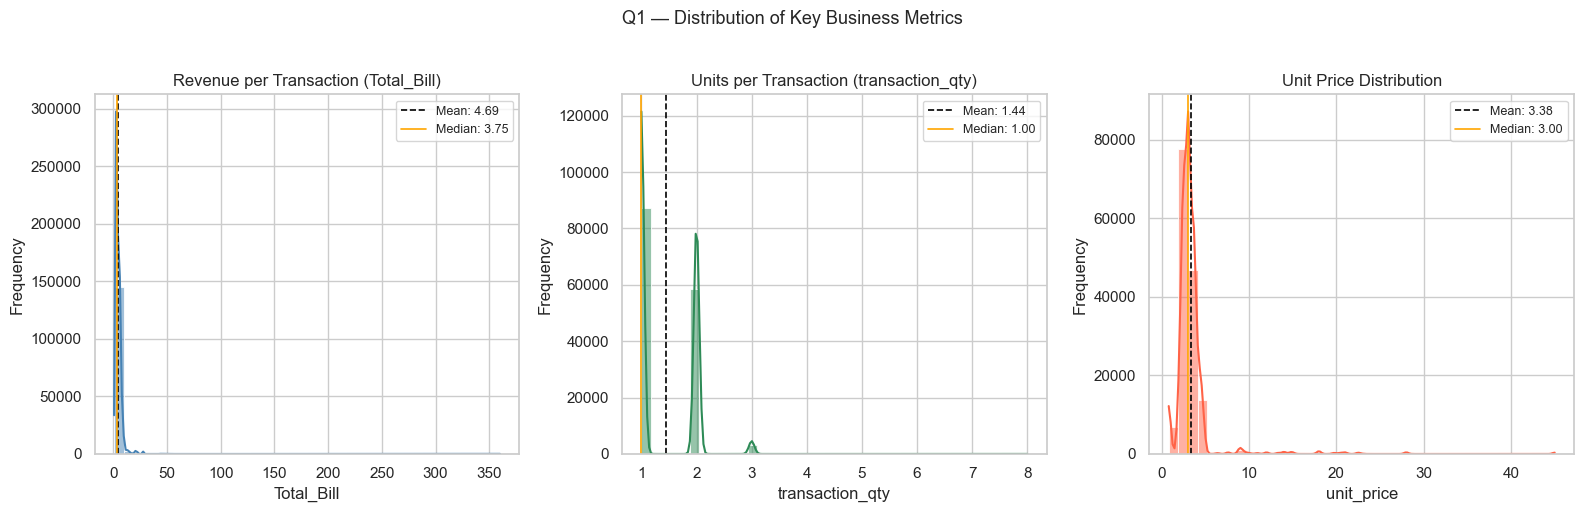

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['steelblue', 'seagreen', 'tomato']
titles = ['Revenue per Transaction (Total_Bill)',
          'Units per Transaction (transaction_qty)',
          'Unit Price Distribution']

for i, (col, color, title) in enumerate(zip(metrics, colors, titles)):
    sns.histplot(df[col], kde=True, ax=axes[i], color=color, bins=40)
    axes[i].axvline(df[col].mean(), color='black', linestyle='--',
                    linewidth=1.2, label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='-',
                    linewidth=1.2, label=f'Median: {df[col].median():.2f}')
    axes[i].set_title(title)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

plt.suptitle('Q1 — Distribution of Key Business Metrics', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Takeaway:** The mean transaction revenue ($4.69) is pulled above the median ($3.75) by a small number of high-value purchases, confirming a right-skewed distribution. The typical customer spends around $3.75 per visit and buys just 1 unit — consistent with a grab-and-go coffee shop model. Unit prices are similarly concentrated in the $2–$5 range, with a long tail from premium products like specialty beans.

### Q1 — Per-Store Descriptive Comparison

In [23]:
store_stats = df.groupby('store_location')['Total_Bill'].agg(
    Mean='mean',
    Median='median',
    Std='std',
    Total_Revenue='sum',
    Transactions='count'
).round(2)

store_stats['Avg_per_transaction'] = store_stats['Total_Revenue'] / store_stats['Transactions']
store_stats['Avg_per_transaction'] = store_stats['Avg_per_transaction'].round(2)

print("=== PER-STORE REVENUE STATISTICS ===")
store_stats

=== PER-STORE REVENUE STATISTICS ===


,Mean,Median,Std,Total_Revenue,Transactions,Avg_per_transaction
store_location,,,,,,
Astoria,4.59,3.75,2.88,232243.91,50599,4.59
Hell's Kitchen,4.66,3.75,5.84,236511.17,50735,4.66
Lower Manhattan,4.81,3.75,3.28,230057.25,47782,4.81


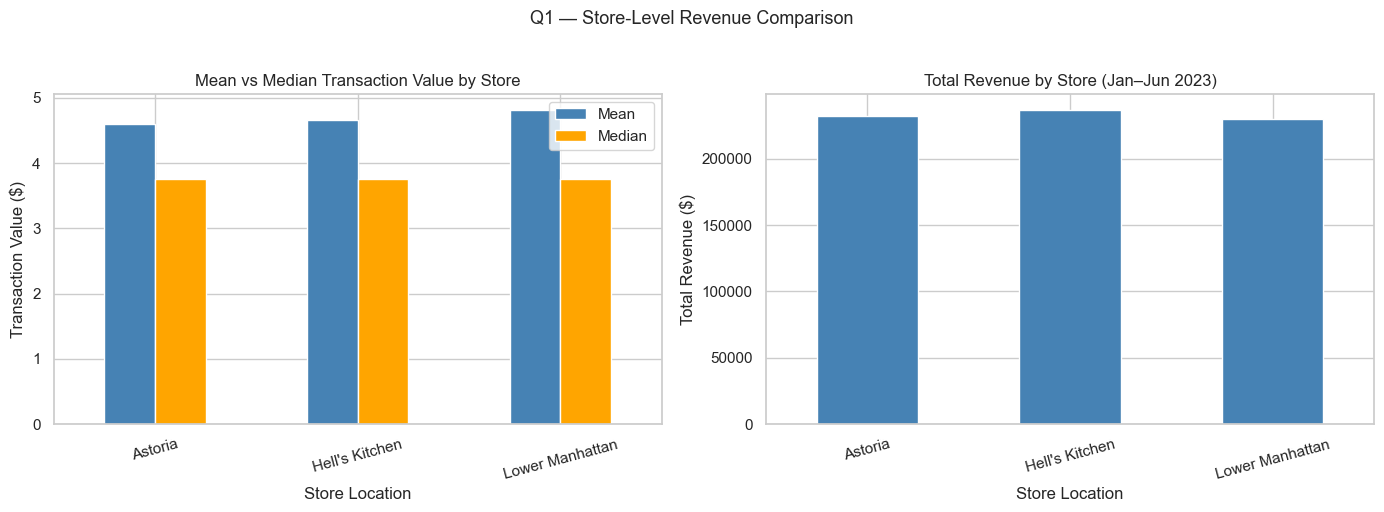

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean vs Median by store
store_stats[['Mean', 'Median']].plot(kind='bar', ax=axes[0],
                                      color=['steelblue', 'orange'],
                                      edgecolor='white')
axes[0].set_title('Mean vs Median Transaction Value by Store')
axes[0].set_xlabel('Store Location')
axes[0].set_ylabel('Transaction Value ($)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)
axes[0].legend(['Mean', 'Median'])

# Total revenue by store
store_stats['Total_Revenue'].plot(kind='bar', ax=axes[1],
                                   color='steelblue', edgecolor='white')
axes[1].set_title('Total Revenue by Store (Jan–Jun 2023)')
axes[1].set_xlabel('Store Location')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

plt.suptitle('Q1 — Store-Level Revenue Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Business Interpretation:** All three stores show nearly identical mean and median transaction values, suggesting consistent pricing and customer behavior across locations. The gap between mean and median at every store confirms that premium purchases skew the average upward equally across all locations, no single store is disproportionately driven by high-value orders. Hell's Kitchen edges out in total revenue, largely due to its slightly higher transaction volume rather than higher spend per visit.